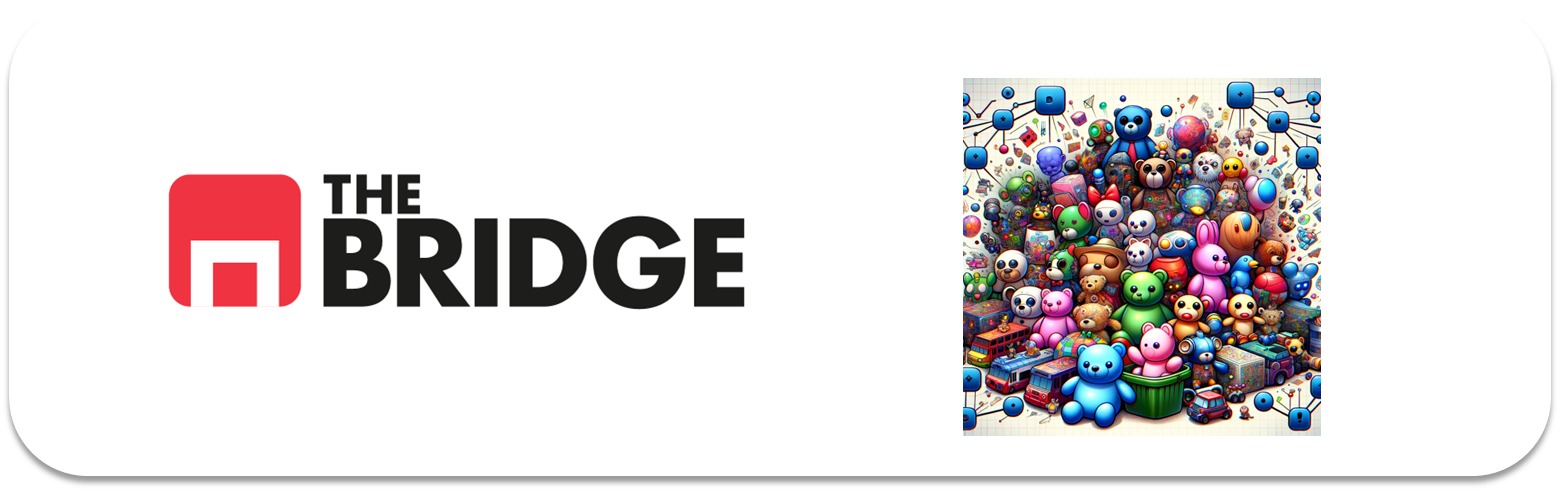

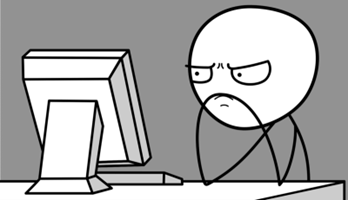

Para ejercitarte y afianzar lo aprendido sobre **DBSCAN**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Problema y "justificación": DBSCAN

Como sabemos, existen diversas técnicas de clusterización comprendidas por algoritmos de machine learning no supervisados, cuya finalidad es agrupar distintos elementos de una data sin la necesidad de estar previamente etiquetados. 

Anteriormente utilizamos el algoritmo de KMeans, sin embargo, dicho algoritmo tiene algunas limitaciones, como el hecho de que no siempre es sencillo obtener un número de K clusters óptimo o que algunas distribuciones de datos no se ajustan a la agrupación por clusters debido a la naturaleza del algoritmo. Para estos casos existen diversos algoritmos de clusterización. 

A continuación, vamos a utilizar el algoritmo DBSCAN (Density-Based Spatial Clustering of Applications with Noise) para capturar grupos en data con patrones relativamente complejos.

Utilizaremos data de clientes de un distribuidor al por mayor, en el que se recogen por línea ventas a diferentes establecimientos y empresas de sus productos (aunque no se incluye el identificador de establecimiento) y cuyo objetivo es obtener agrupaciones interesantes (agrupaciones no predefinidas de productos que se suelen comprar juntos):

Features:

    1) FRESH: Gastos en productos frescos;
    2) MILK: Gastos en productos lacteos;
    3) GROCERY: Gastos en comestibles;
    4) FROZEN: Gastos en congelados;
    5) DETERGENTS_PAPER: Gastos en detergentes y derivados del papel;
    6) DELICATESSEN: Gatos en comestibles finos;
    7) CHANNEL: Canal que utilizan los clientes para vender - Horeca (Hotel/Restaurant/Cafeterías) o Retail channel (Al por menor);
    8) REGION: Región del cliente;

Fuente: https://archive.ics.uci.edu/ml/datasets/Wholesale+customers

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Common imports
import numpy as np
import pandas as pd
import seaborn as sns

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")


### Ejercicio 1

Carga los datos y haz una primera exploración, incluyendo una descripción de las variables numéricas.

In [2]:
df = pd.read_csv("./data/wholesale-customers-data.csv")
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
print(df.describe())

          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    440.000000        440.000000    440.000000  
mean    3071.931818       2881.493182   1524.870455  
std     4854.673333       4767.854448   2820.105937  
min       25.000000          3.000000      3.000000  
25%      742.250000        256.750000    408.

$$***$$

Es hora de hacer un miniEda (cuyo objetivo en el caso de clusterizacion no es obtener features para predicción de un target que no tenemos), cuyo objetivo es poder intuir posibles agrupaciones y su número, detectar si hay que hacer transformaciones y escalado en las variables y cuál

### Ejercicio 2



Pinta el histograma de las variables y determina cuáles podríamos considerar numéricas continuas y cuáles numéricas discretas (o categóricas)

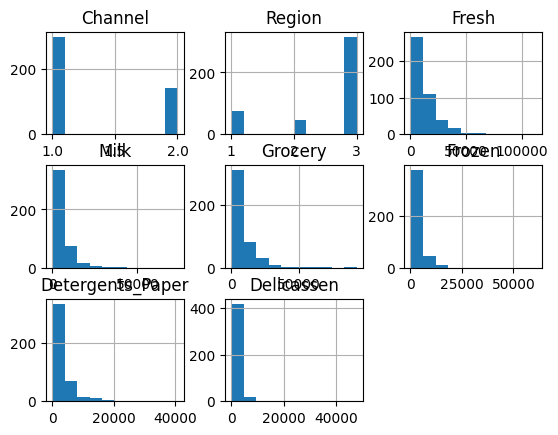

In [5]:
df.hist();

In [6]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

'Channel', 'Region' son categóricas.  
El resto son numéricas continuas.

### Ejercicio 3

Antes de decidir sobre las agrupaciones, vamos pintar los histrogramas pero separando por canal (ya que es un elemento muy diferenciador del tipo de venta que se realiza a mayorista). Muestra graficamente para cada variable numérica su histograma para cada canal (Horeca y Retail). 

In [7]:
# features_num = ['Fresh', 'Milk', 'Grocery', 'Frozen',
#      'Detergents_Paper', 'Delicassen']
#
# for col in features_num:
#   histo = df.groupby('Channel')[col]
# n_rows = len(features_num)//2
# fig, ax = plt.subplots(n_rows, 2, figsize=(n_rows*2, 8))
#
# for i , valor in histo:
#    ax[i] = histo.hist();
#    plt.title(col)

# plt.tight_layout()
# plt.show()

# ERRORES EN MI CÓDIGO:
# 1. El primer for sobreescribe histo en cada iteración.
# Solo guarda el groupby de la última columna (Delicassen), las demás se pierden.

# 2. El segundo for itera mal sobre ax y histo
# "for i, valor in histo" itera sobre los grupos del Channel, no sobre las features.
#  Además col nunca cambia dentro de ese bucle.

# 3. ax[i] no usa índices de fila/columna correctamente
# Con plt.subplots(n_rows, 2, ...) necesitas indexar como ax[fila, columna].


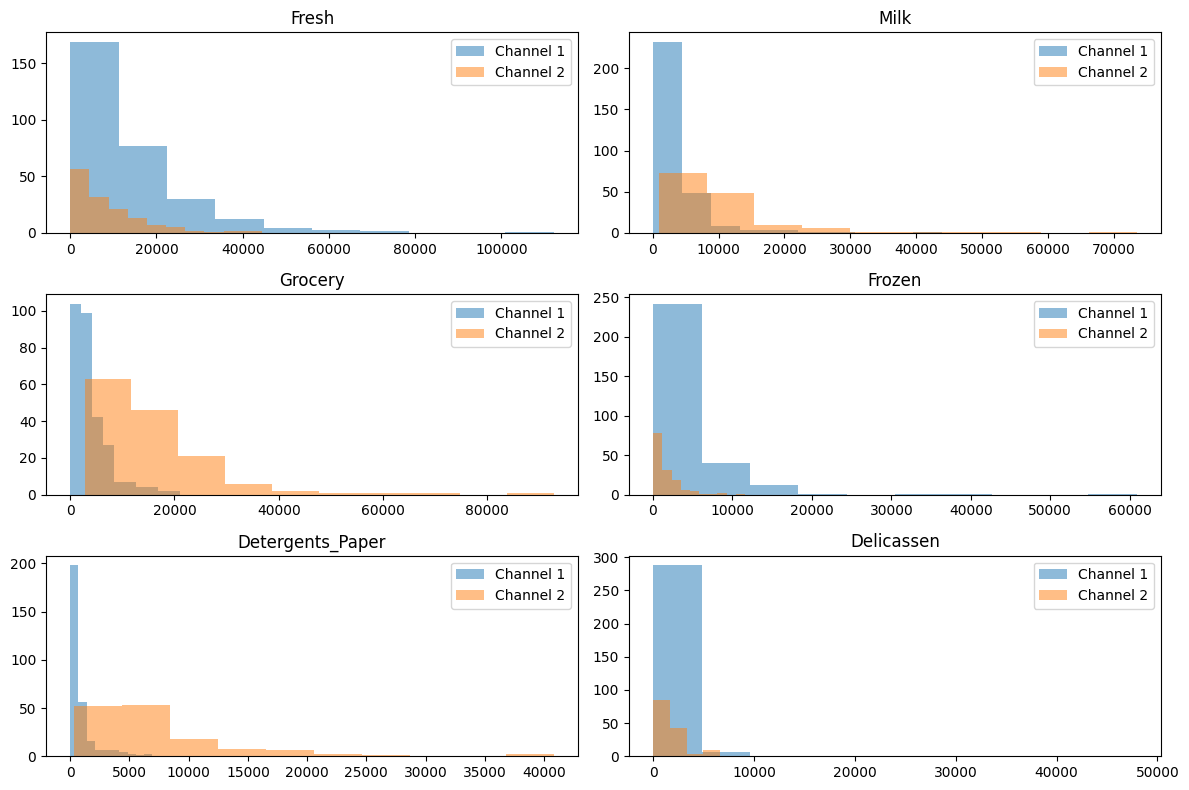

In [8]:
features_num = ['Fresh', 'Milk', 'Grocery', 'Frozen',
                'Detergents_Paper', 'Delicassen']

n_rows = len(features_num) // 2
fig, ax = plt.subplots(n_rows, 2, figsize=(12, 8))

for i, col in enumerate(features_num):  #Con enumerate todo ocurre dentro del mismo bucle,
    # por lo que cada columna se dibuja en su subplot antes de pasar a la siguiente.
    fila = i // 2
    columna = i % 2    # Resto de la división

    # Iterar sobre los grupos del Channel para cada feature
    for channel, grupo in df.groupby('Channel')[col]:
        ax[fila, columna].hist(grupo, alpha=0.5, label=f'Channel {channel}')

    ax[fila, columna].set_title(col)
    ax[fila, columna].legend()

plt.tight_layout()
plt.show()

### Ejercicio 4

Analicemos los outliers. Obten los outliers a partir de los diagramas de boxplot para todos los datos y luego separados por canal.

In [9]:
# n_rows = len(features_num) // 2
# fig, ax = plt.subplots(n_rows, 2, figsize=(12, 8))
# for i, col in enumerate(features_num):
#    fila = i // 2
#    columna = i % 2 
#    for i, col in enumerate(df[features_num]):
#        ax[fila, columna] = sns.boxplot(x = col , data = df);
# ax[fila, columna].set_xlabel(f"{col}")
# ax[fila, columna].set_ylabel("Count")

# plt.tight_layout()
# plt.show();


# ERROR EN MI CÓDIGO:
# Tienes dos for anidados que usan las mismas variables i y col,
#  el interior sobreescribe al exterior. Solo hace falta uno.
# sns.boxplot no se asigna con =, se le pasa el ax como parámetro:

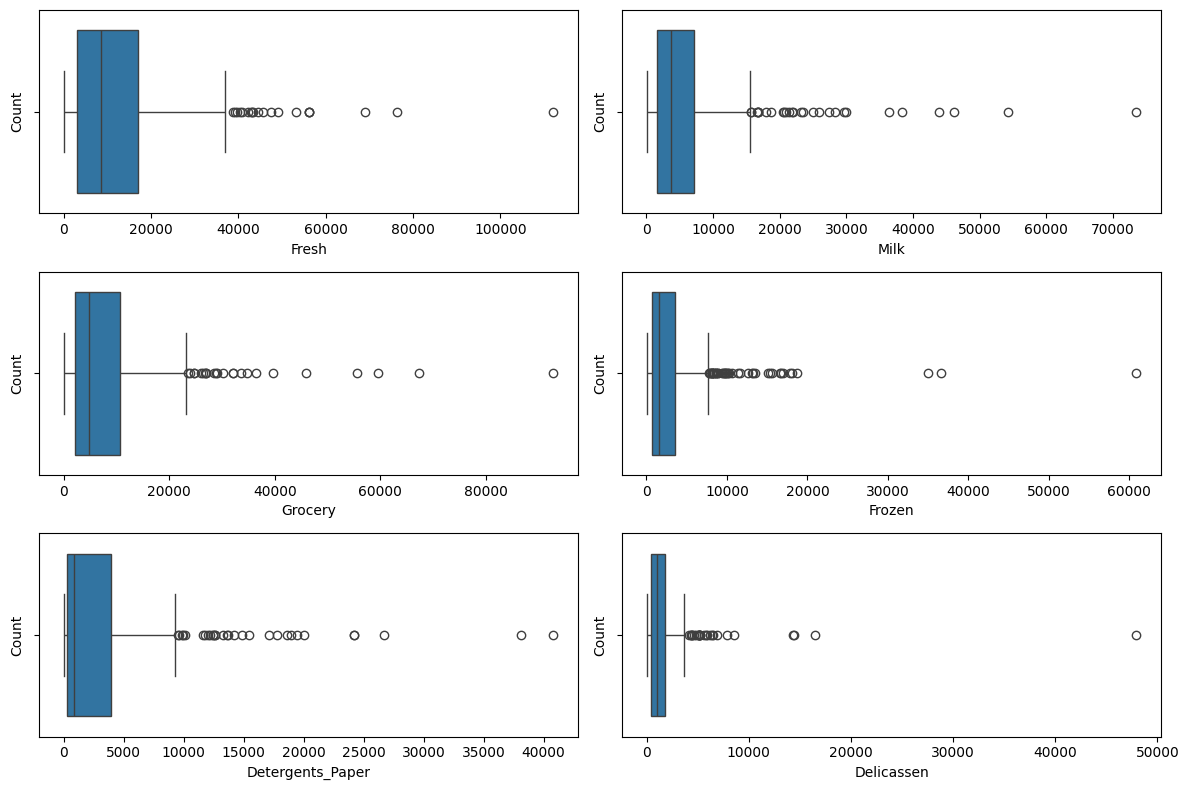

In [10]:
n_rows = len(features_num) // 2
fig, ax = plt.subplots(n_rows, 2, figsize=(12, 8))
for i, col in enumerate(features_num):
    fila = i // 2
    columna = i % 2 
    sns.boxplot(x=col, data=df, ax=ax[fila, columna])  #  se pasa ax=
    ax[fila, columna].set_xlabel(col)                   #  dentro del bucle
    ax[fila, columna].set_ylabel("Count")               #  dentro del bucle

plt.tight_layout()
plt.show()

In [11]:
def plot_grouped_boxplots(df, cat_col, num_col):
    unique_cats = df[cat_col].unique()
    num_cats = len(unique_cats)
    group_size = 5

    for i in range(0, num_cats, group_size):
        subset_cats = unique_cats[i:i+group_size]
        subset_df = df[df[cat_col].isin(subset_cats)]
        
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=cat_col, y=num_col, data=subset_df)
        plt.title(f'Boxplots of {num_col} for {cat_col} (Group {i//group_size + 1})')
        plt.xticks(rotation=45)
        plt.show()

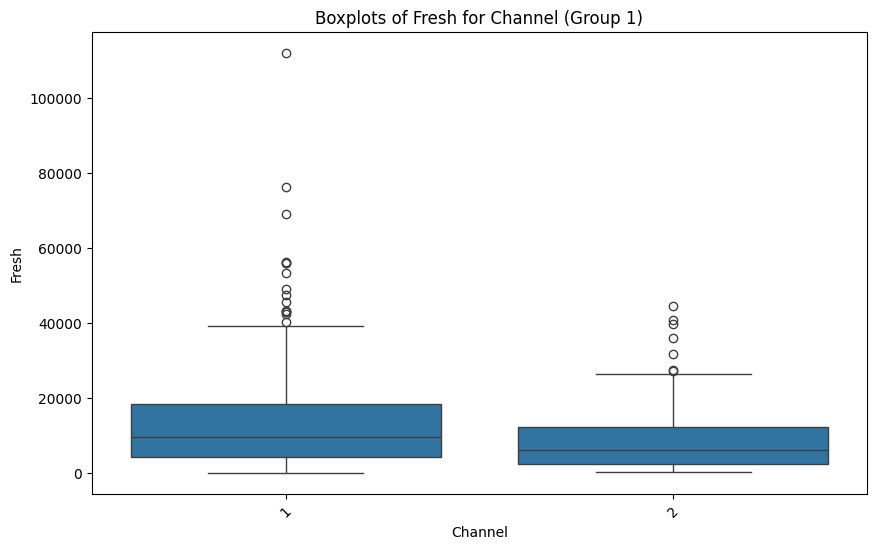

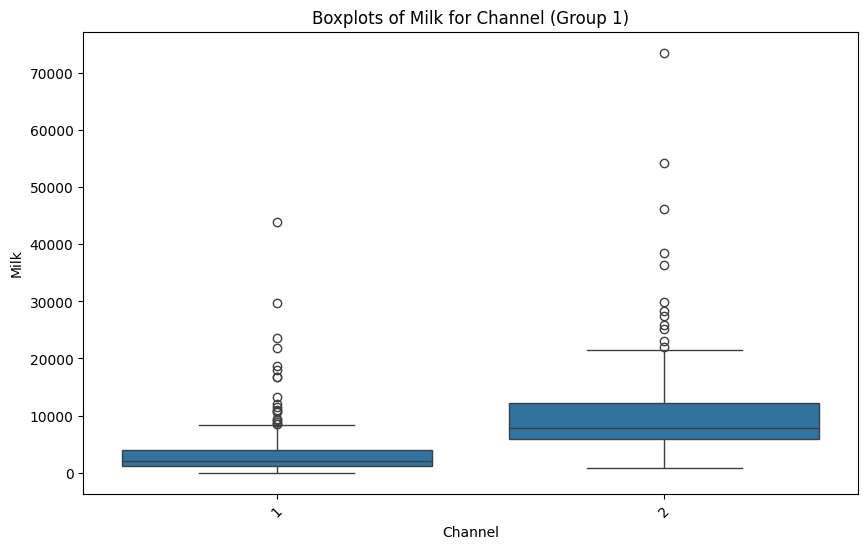

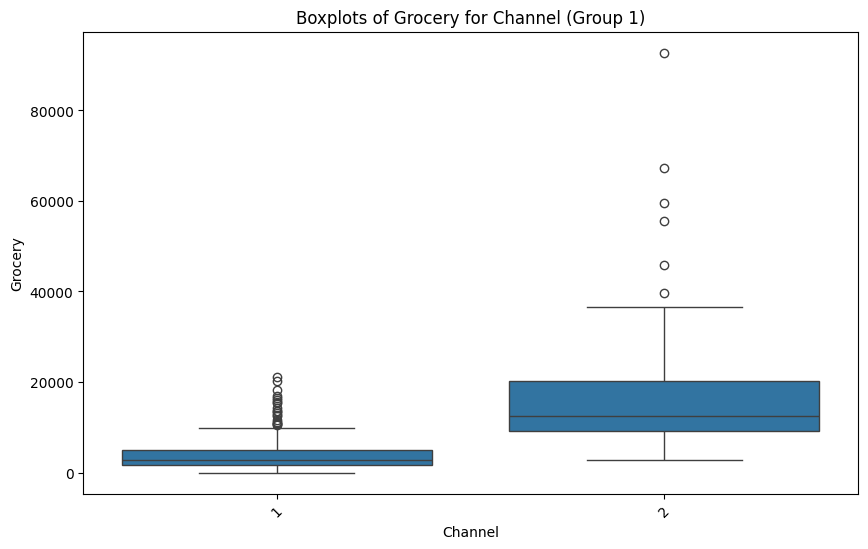

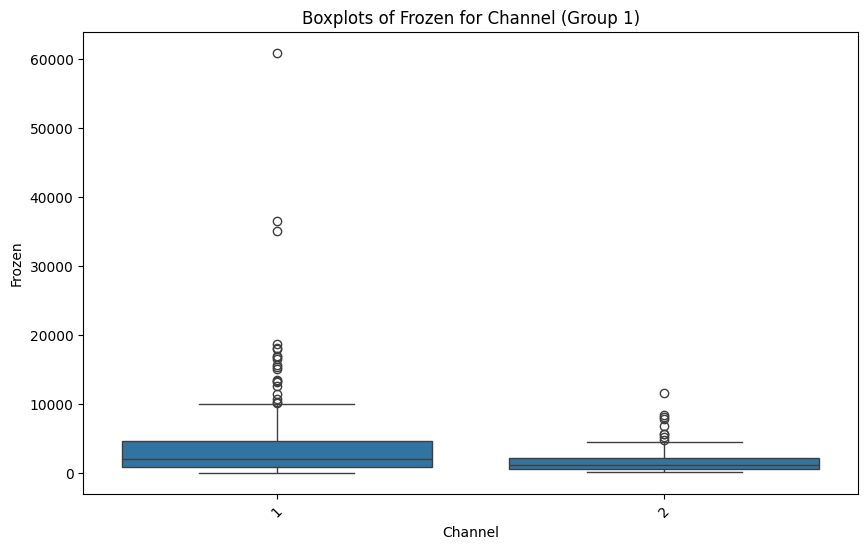

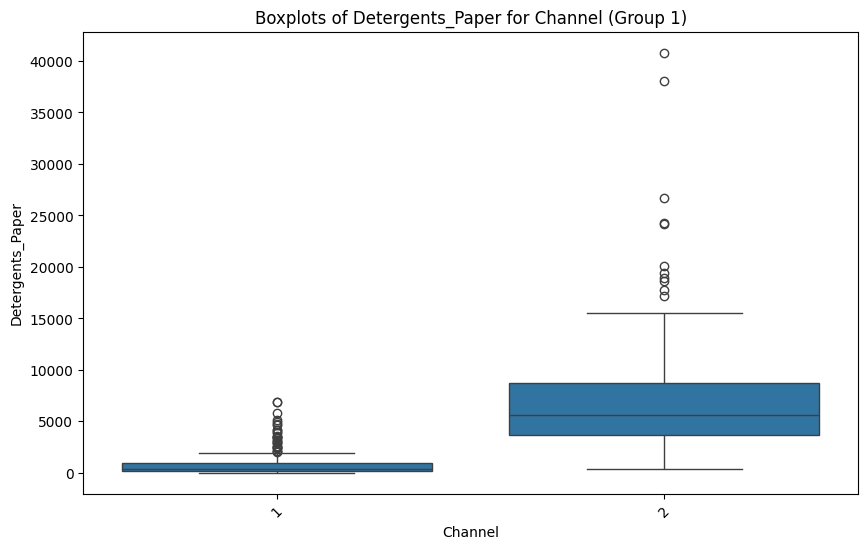

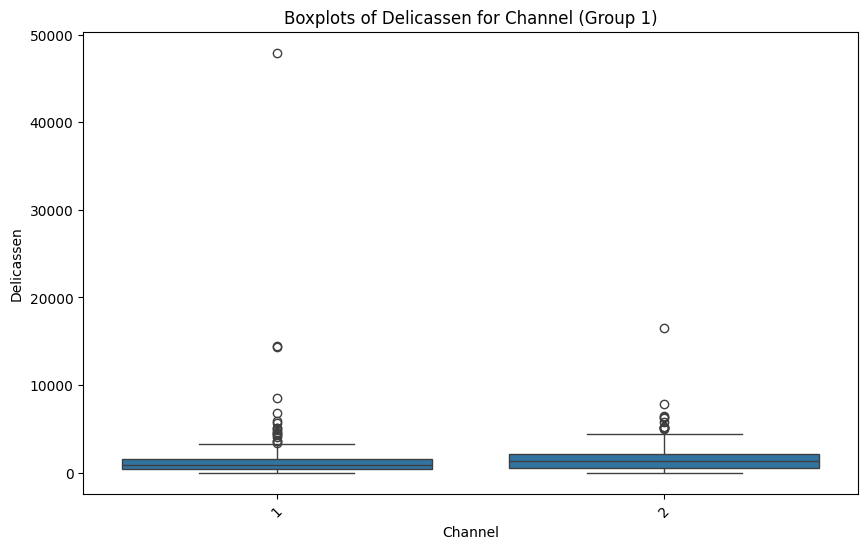

In [12]:
for i, col in enumerate(features_num):
    plot_grouped_boxplots(df, 'Channel', col)

### Ejercicio 5

Vamos a intentar detectar posibles agrupaciones en los datos con variables dos a dos. Utiliza un pairplot de sns para mostrar los scatter plots de las variables numéricas dos a dos e intentar visualizar algún clustering e incluso justificar usar kMeans o DBSCAN. En este ejercicio hazlo para todo el dataset.

In [13]:
features_num

['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

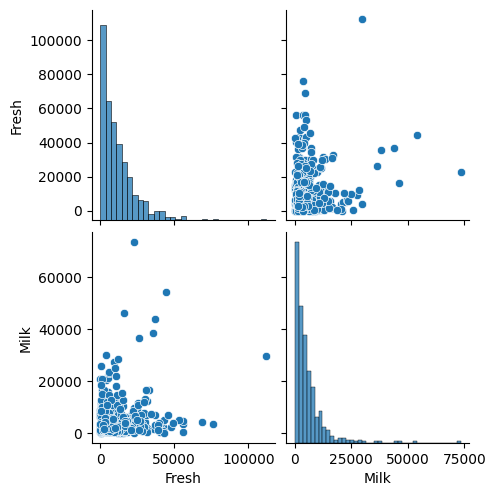

In [14]:
sns.pairplot(df[['Fresh', 'Milk']]);

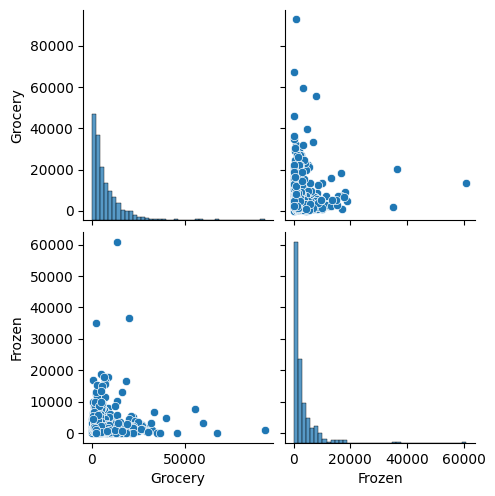

In [15]:
sns.pairplot(df[['Grocery', 'Frozen']]);

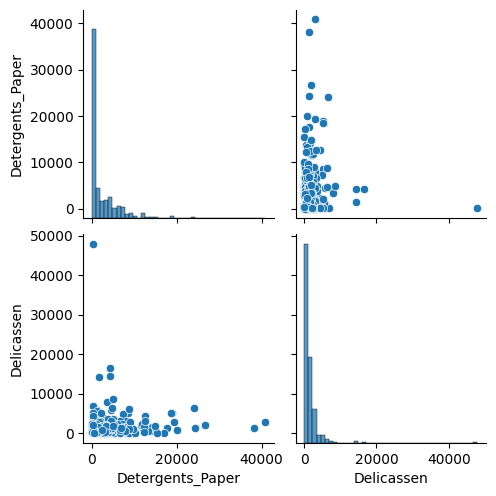

In [16]:
sns.pairplot(df[['Detergents_Paper', 'Delicassen']]);

### Ejercicio 6

Repite el ejercicio 5 pero separando por canal. Emplea el argumento hue del pairplot para no tener que hacer dos pairplots diferentes. 

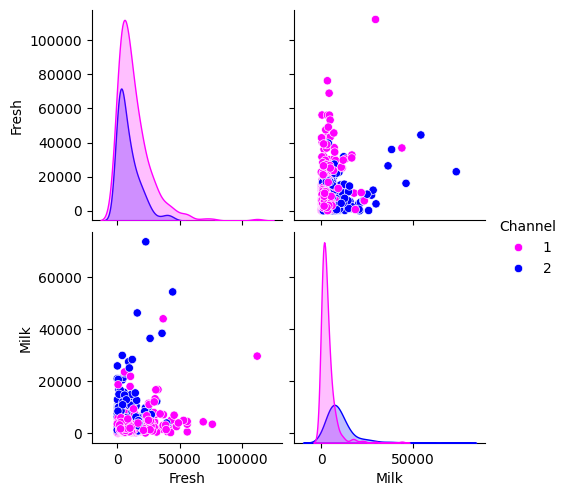

In [17]:
# sns.pairplot(df[['Fresh', 'Milk']], hue="Channel"); ERROR "Channel" tiene que estar en el df
sns.pairplot(df[['Fresh', 'Milk', 'Channel']], hue="Channel", palette=['magenta', 'blue']);

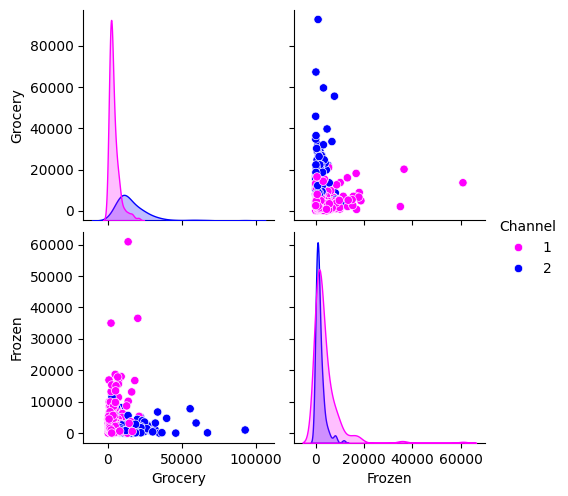

In [18]:
sns.pairplot(df[['Grocery', 'Frozen', 'Channel']], hue="Channel", palette=['magenta', 'blue']);

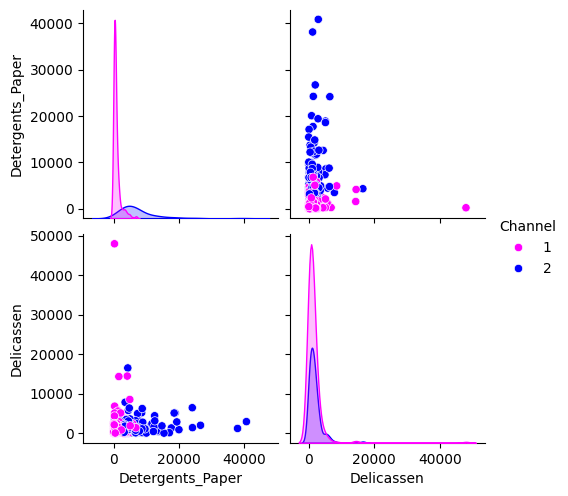

In [19]:
sns.pairplot(df[['Detergents_Paper', 'Delicassen', 'Channel']], hue="Channel", palette=['magenta', 'blue']);

### Ejercicio 7

Si has logrado hacer los dos ejercicios anteriores (y si no consulta su solución) tendrás una idea un poco más clara de por qué es interesante la clusterización con DBSCAN mejor que con KMeans. Así que vamos a utilizarlo, pero antes escalemos los datos, transformándolos primero (de primeras no vamos a distinguir entre canales, hazlo con todo el dataset). Es decir aplica la tranformación que creas necesaria en las columnas numéricas que creas conveniente. Hazlo en un dataframe copiado del original para poder interpretar los valores correctamente al final.

pairplots:  
Outliers muy marcados (puntos azules muy alejados del grupo).
Distribuciones con cola larga (sesgo a la derecha en los histogramas).
Clusters de forma irregular, no esférica.
Densidad muy desigual entre grupos.
Conclusión: DBSCAN es mejor opción 

|Criterio|KMeans|DBSCAN|
|---|---|---|
|Outliers|❌ Los absorbe en clusters|✅ Los marca como ruido|
|Forma de clusters|❌ Asume forma esférica|✅ Detecta cualquier forma|
|Densidad desigual|❌ Le afecta|✅ Se adapta|
|Nº de clusters|❌ Hay que definirlo|✅ Lo detecta solo|

In [20]:
# No voy a transformar las features categóricas, no tiene sentido
df_transformado = df.copy()
df_transformado[features_num] = np.log(df[features_num])

### Ejercicio 8

Escala las columnas que creas necesario. Si no lo tienes claro, escala todas.

Escalar un 1, 2 ('Channel') o 1, 2, 3 ('Region') categórico no tiene sentido matemático, el modelo interpretaría que hay una distancia ordinal entre categorías cuando no la hay.

In [21]:
from sklearn.preprocessing import RobustScaler
escalado= RobustScaler()

df_scaled = pd.DataFrame(escalado.fit_transform(df_transformado[features_num]), 
                          columns=features_num)

df_scaled.index = df_transformado.index  # asegurar que el índice coincide

# pd.concat necesita una lista []
# 'index' no es parámetro de pd.concat
df_modelado = pd.concat([df_transformado[["Channel", "Region"]], df_scaled], axis=1)


### Ejercicio 9

En el caso de los modelos no supervisados, una vez hemos tratado las features hay que escoger los hiperparámetros. En el caso de dBSCAN no es el número de clústeres, sino la distancia `eps` que determina el vecindario de un punto y el número de vecinos a partir del cual se decide si una instancia es core o no (`min_samples`). 

Una forma de hacerlo es iterar sobre rangos de estos dos hiperparámetros midiendo el porcentaje de "anomalías" que detecta y considerando como punto de parada un valor por debajo del 10%.

NOTA: Usa el doble de cantidad de tus features para el mínimo de elementos y un rango para el epsilon de 0.001 a 3. Para min_samples vamos a usar un valor "estimado" que corresponde a 2 veces el número de features empleadas.

In [22]:
from sklearn.cluster import DBSCAN
rango_eps = np.arange(0.001, 3, 0.002)
for e in rango_eps:
    dbscan = DBSCAN(eps= e, min_samples=16, n_jobs=-1).fit(df_modelado)

# Detectar anomalías y parar antes de llegar al 10%.
# Detectarlas:
    labels = dbscan.labels_
    n_anomalias = np.sum(labels == -1)          # DBSCAN etiqueta anomalías como -1
    pct_anomalias = n_anomalias / len(labels)   # Porcentajes

    # Parar:
    
    
    if pct_anomalias < 0.10:                    # punto de parada < 10%
        print(f"eps óptimo encontrado: {e:.3f}")
        break
               

eps óptimo encontrado: 1.475


### Ejercicio 10

Entrena un clustering DBSCAN con el valor que hayas encontrado como mejor en el ejercicio anterior (si no has visto claramente un valor, usa eps = 2) y `min_samples` a dos veces el número de features empleadas.

In [23]:
clustering= DBSCAN(eps= 1.475, min_samples=16, n_jobs=-1)
clustering.fit(df_modelado)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1.475
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",16
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


### Ejercicio 11

Agrega las etiquetas generadas con DBSCAN a tu dataframe original e interpreta los resultados (observa el número de etiquetas, recuerda que -1 no es un cluster son anomalías o outliers) luego contesta a: ¿Qué grupos o patrones fué capaz de capturar el DBSCAN? (Haz las tablas de contingencia de las etiquetas con las dos variables categóricas, por separado, por ejemplo y a partir de ahí justifica tu respuesta)

In [24]:
etiquetas = clustering.labels_
df["etiquetas"]= etiquetas
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen', 'etiquetas'],
      dtype='object')

In [25]:
tabla_canal = pd.crosstab(df["Channel"], df["etiquetas"])
print(tabla_canal)

etiquetas  -1    0
Channel           
1          29  269
2          14  128


In [26]:
tabla_region = pd.crosstab(df["Region"], df["etiquetas"])
print(tabla_region)

etiquetas  -1    0
Region            
1          11   66
2           4   43
3          28  288


Con un epsilon de 1.475 está generando un solo cluster y dejando fuera solo a los outliers. No está encontrando patrones internos a partir de los cuales dividir en más de un cluster el dataset. Teniendo en cuenta las gráficas no parece extraño, ya que se ve todos los puntos aglutinados (0) y los alejados y dispersos (-1).  
En este caso DBSCAN es útil precisamente para identificar esas anomalías, no necesariamente para segmentar.